In [1]:
import torch
import importlib
import numpy as np
from scipy.optimize import minimize
from modele import *
from visualisation import *
import pytorch_optim
importlib.reload(pytorch_optim)
from pytorch_optim import *
%load_ext autoreload
%autoreload 2


In [2]:
N=10
nb_colonnes_default = 50
T = 300
L = 5
P0 = torch.tensor([[0, 1 / 2, 1], [1 / 2, 0, 0], [1 / 2, 1 / 2, 0]]) 
params = {
    "N": N,  # nombre de couches
    "L": L,  # longueur du bassin
    "H": 1,  # hauteur du bassin
    "nb_colonnes_default": 50,  # discrétisation horizontale
    "D": 1e-5,  # coefficient de diffusion
    "T": T,  # temps final pour 20 tours
    "CFL": 0.95,  # facteur CFL
    "u" : [0.1]*N,
    "I_s": 2000, #1500 initialement
    "epsilon": 3, #4.6 pour une luminosité de 1% au fond du bassin
    "k_d": 2.99e-4,   # 2.99*10e-5 = 2.99e-4
    "k_r": 4.8e-4,    # 4.8*10e-5 = 4.8e-4
    "k_h": 3.64e-4,   # 3.64*10e-5 = 3.64e-4
    "tau": 6.849,
    "sigma_H": 2.9e-3,  # 2.9*10e-4 = 2.9e-3
    "theta": 3.64e-4 * 2.9e-3,  # k_h * sigma_H
    "I_star": np.sqrt(4.8e-4 / (2.99e-4 * 6.849 * (2.9e-3)**2)),
    "mu_max": 3.64e-4 * 2.9e-3 / (6.849 * 2.9e-3 + 2*np.sqrt((2.99e-4 * 6.849 * (2.9e-3)**2)/4.8e-4))
}

In [10]:

P, biomass_list = solve_bistochastique(X_ini_one_layer_torch(N, nb_colonnes_default), T, params, 30, 1000, 0.2, True, torch.eye(N))
print(P)

obj: tensor(50.0076, grad_fn=<AddBackward0>) pen: tensor(0., grad_fn=<SumBackward0>)
obj: tensor(50.0080, grad_fn=<AddBackward0>) pen: tensor(0.3318, grad_fn=<SumBackward0>)
obj: tensor(50.0077, grad_fn=<AddBackward0>) pen: tensor(0.0233, grad_fn=<SumBackward0>)
obj: tensor(50.0074, grad_fn=<AddBackward0>) pen: tensor(0.0861, grad_fn=<SumBackward0>)
obj: tensor(50.0073, grad_fn=<AddBackward0>) pen: tensor(0.1936, grad_fn=<SumBackward0>)
obj: tensor(50.0074, grad_fn=<AddBackward0>) pen: tensor(0.1129, grad_fn=<SumBackward0>)
obj: tensor(50.0073, grad_fn=<AddBackward0>) pen: tensor(0.0151, grad_fn=<SumBackward0>)
obj: tensor(50.0078, grad_fn=<AddBackward0>) pen: tensor(0.0102, grad_fn=<SumBackward0>)
obj: tensor(50.0077, grad_fn=<AddBackward0>) pen: tensor(0.0661, grad_fn=<SumBackward0>)
obj: tensor(50.0076, grad_fn=<AddBackward0>) pen: tensor(0.0963, grad_fn=<SumBackward0>)
obj: tensor(50.0077, grad_fn=<AddBackward0>) pen: tensor(0.0721, grad_fn=<SumBackward0>)
obj: tensor(50.0077, grad

Test : flashing effect

In [ ]:
params["N"] = 5
params["u"] = [0.1]*5
matrices = {}
biomasses = {}
for l in [1, 5, 10, 25, 50] :
    params["nb_colonnes_default"] = l*10
    params["L"] = l
    P, biomass_list = solve_bistochastique(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    matrices[f'P{l}'] = P
    biomasses[f'B{l}'] = biomass_list
    print(P, biomass_list[-1])

obj: tensor(50.3585, grad_fn=<AddBackward0>) pen: tensor(0.0812, grad_fn=<SumBackward0>)
obj: tensor(50.3524, grad_fn=<AddBackward0>) pen: tensor(0.0356, grad_fn=<SumBackward0>)
obj: tensor(50.3463, grad_fn=<AddBackward0>) pen: tensor(0.0504, grad_fn=<SumBackward0>)
obj: tensor(50.3453, grad_fn=<AddBackward0>) pen: tensor(0.0359, grad_fn=<SumBackward0>)
obj: tensor(50.3474, grad_fn=<AddBackward0>) pen: tensor(0.0336, grad_fn=<SumBackward0>)
obj: tensor(50.3509, grad_fn=<AddBackward0>) pen: tensor(0.0218, grad_fn=<SumBackward0>)
obj: tensor(50.3540, grad_fn=<AddBackward0>) pen: tensor(0.0096, grad_fn=<SumBackward0>)
obj: tensor(50.3556, grad_fn=<AddBackward0>) pen: tensor(0.0120, grad_fn=<SumBackward0>)
obj: tensor(50.3554, grad_fn=<AddBackward0>) pen: tensor(0.0200, grad_fn=<SumBackward0>)
obj: tensor(50.3539, grad_fn=<AddBackward0>) pen: tensor(0.0212, grad_fn=<SumBackward0>)
obj: tensor(50.3520, grad_fn=<AddBackward0>) pen: tensor(0.0157, grad_fn=<SumBackward0>)
obj: tensor(50.3503, 

In [19]:
params["N"] = 3
params["u"] = [0.1]*3
matrices = {}
biomasses = {}
for l in [0.3, 1, 5, 10, 15, 20, 25, 50, 75, 100, 150] :
    params["nb_colonnes_default"] = int(l*10)
    params["L"] = l
    meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    print(meilleure_masse, meilleure_matrice)

50.32933169061667 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.32968454422438 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.32871725242194 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.328364351760364 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.359217978920285 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.35983356257357 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.34525989963021 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.26297024241707 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.23288691970242 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.21784525834525 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.20280359698786 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


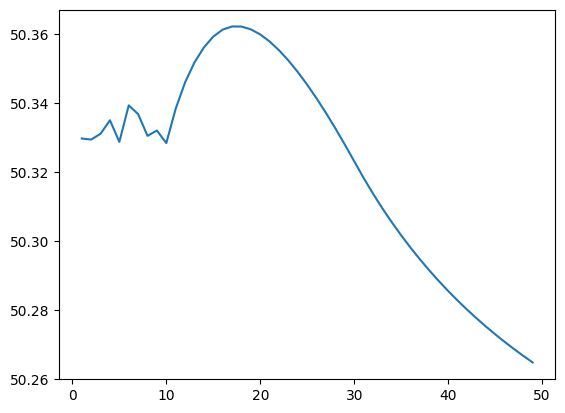

In [4]:
params["N"] = 3
params["u"] = [0.1]*3
masses = []
for l in range(1, 50):
    params["nb_colonnes_default"] = int(l*10)
    params["L"] = l
    meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    masses.append(meilleure_masse)
    
plt.plot([k for k in range(1, 50)], masses)

In [18]:
params["N"] = 4
params["u"] = [0.1]*4
matrices = {}
biomasses = {}
for l in [1, 2, 5, 10, 15, 25, 50, 100] :
    params["nb_colonnes_default"] = int(l*10)
    params["L"] = l
    meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    print(meilleure_masse, meilleure_matrice)

50.36270884925297 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.362055017802554 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.36103093516114 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.37371633553097 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.39057609279154 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.35809548480737 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.26899199693378 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.22085613560361 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


Trouver à présent le gain de biomasse pour une matrice bistochastique en partant d'une matrice de permutation.

In [59]:
params["N"] = 4
params["u"] = [0.1]*4
params["nb_colonnes_default"] = 50
params["L"] = 5
meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 1), T, params)
print(meilleure_masse, meilleure_matrice)

50.36103093516114 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


In [67]:
M = [[float(m) for m in l] for l in meilleure_matrice]
print(M)
M = inverse_softmax(M)
print(M)
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"]), T, params, 50, 1000, 0.2, True, torch.tensor(M))

[[0.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0]]
[[-5.0, -5.0, 0.0, -5.0], [-5.0, 0.0, -5.0, -5.0], [-5.0, -5.0, -5.0, 0.0], [0.0, -5.0, -5.0, -5.0]]
tensor([[0.0066, 0.0066, 0.9802, 0.0066],
        [0.0066, 0.9802, 0.0066, 0.0066],
        [0.0066, 0.0066, 0.0066, 0.9802],
        [0.9802, 0.0066, 0.0066, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3602, grad_fn=<AddBackward0>) pen: tensor(1.0658e-14, grad_fn=<SumBackward0>)
tensor([[0.0045, 0.0098, 0.9739, 0.0044],
        [0.0045, 0.9707, 0.0066, 0.0044],
        [0.0045, 0.0098, 0.0098, 0.9845],
        [0.9866, 0.0098, 0.0098, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3612, grad_fn=<AddBackward0>) pen: tensor(0.0005, grad_fn=<SumBackward0>)
tensor([[0.0060, 0.0073, 0.9788, 0.0060],
        [0.0060, 0.9781, 0.0066, 0.0060],
        [0.0060, 0.0073, 0.0073, 0.9814],
        [0.9821, 0.0073, 0.0073, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3605, grad_fn=<AddBack

In [68]:
print(P_bisto)

tensor([[0.0018, 0.0020, 0.9945, 0.0014],
        [0.0016, 0.9944, 0.0023, 0.0013],
        [0.0024, 0.0018, 0.0015, 0.9947],
        [0.9942, 0.0018, 0.0016, 0.0027]], grad_fn=<SoftmaxBackward0>)


In [69]:
params["N"] = 3
params["u"] = [0.1]*3
params["nb_colonnes_default"] = 50
params["L"] = 5
meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 1), T, params)
print(meilleure_masse, meilleure_matrice)

50.32871725242194 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [70]:
M = [[float(m) for m in l] for l in meilleure_matrice]
print(M)
M = inverse_softmax(M)
print(M)
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"]), T, params, 50, 1000, 0.2, True, torch.tensor(M))

[[0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [1.0, 0.0, 0.0]]
[[-5.0, 0.0, -5.0], [-5.0, -5.0, 0.0], [0.0, -5.0, -5.0]]
tensor([[0.0066, 0.9867, 0.0066],
        [0.0066, 0.0066, 0.9867],
        [0.9867, 0.0066, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3294, grad_fn=<AddBackward0>) pen: tensor(0., grad_fn=<SumBackward0>)
tensor([[0.0045, 0.9803, 0.0098],
        [0.0045, 0.0099, 0.9803],
        [0.9910, 0.0099, 0.0099]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3300, grad_fn=<AddBackward0>) pen: tensor(0.0002, grad_fn=<SumBackward0>)
tensor([[0.0060, 0.9827, 0.0099],
        [0.0060, 0.0099, 0.9828],
        [0.9880, 0.0073, 0.0073]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3296, grad_fn=<AddBackward0>) pen: tensor(1.0647e-05, grad_fn=<SumBackward0>)
tensor([[0.0081, 0.9851, 0.0102],
        [0.0081, 0.0093, 0.9842],
        [0.9839, 0.0056, 0.0056]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3292, grad_fn=<AddBackward0>) pen: tensor(3.8205e-05, grad_fn=<SumBackward0>)
tensor

In [71]:
print(P_bisto)

tensor([[0.0016, 0.9935, 0.0047],
        [0.0016, 0.0048, 0.9935],
        [0.9968, 0.0017, 0.0017]], grad_fn=<SoftmaxBackward0>)


Et maintenant avec d'autres configurations initiales. D'abord, uniforme.

In [73]:
params["N"] = 3
params["u"] = [0.1]*3
params["nb_colonnes_default"] = 50
params["L"] = 5
meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_uniform(params["N"], params["nb_colonnes_default"], 1), T, params)
print(meilleure_masse, meilleure_matrice)

150.98712016540446 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [78]:
M = [[float(m) for m in l] for l in meilleure_matrice]
print(M)
M = inverse_softmax(M)
print(M)
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_uniform_torch(params["N"], params["nb_colonnes_default"]), T, params, 50, 1000, 0.2, True, torch.tensor(M))

[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]
[[0.0, -10.0, -10.0], [-10.0, 0.0, -10.0], [-10.0, -10.0, 0.0]]
tensor([[9.9991e-01, 4.5396e-05, 4.5396e-05],
        [4.5396e-05, 9.9991e-01, 4.5396e-05],
        [4.5396e-05, 4.5396e-05, 9.9991e-01]], grad_fn=<SoftmaxBackward0>)
obj: tensor(150.9874, grad_fn=<AddBackward0>) pen: tensor(3.5527e-15, grad_fn=<SumBackward0>)
tensor([[9.9986e-01, 3.0435e-05, 3.0433e-05],
        [6.7709e-05, 9.9992e-01, 3.0434e-05],
        [6.7712e-05, 4.5395e-05, 9.9994e-01]], grad_fn=<SoftmaxBackward0>)
obj: tensor(150.9876, grad_fn=<AddBackward0>) pen: tensor(8.7743e-09, grad_fn=<SumBackward0>)
tensor([[9.9980e-01, 2.5664e-05, 2.0807e-05],
        [9.9297e-05, 9.9992e-01, 2.0716e-05],
        [9.9381e-05, 5.5960e-05, 9.9996e-01]], grad_fn=<SoftmaxBackward0>)
obj: tensor(150.9878, grad_fn=<AddBackward0>) pen: tensor(3.7599e-08, grad_fn=<SumBackward0>)
tensor([[9.9971e-01, 2.4487e-05, 1.5184e-05],
        [1.4514e-04, 9.9990e-01, 1.4964e-05],
        [

Avec Newton :

In [8]:
print(params)

{'N': 3, 'L': 5, 'H': 1, 'nb_colonnes_default': 50, 'D': 1e-05, 'T': 300, 'CFL': 0.95, 'u': [0.01, 0.01, 0.01], 'I_s': 1500, 'epsilon': 4.6, 'k_d': 0.000299, 'k_r': 0.00048, 'k_h': 0.000364, 'tau': 6.849, 'sigma_H': 0.0029, 'theta': 1.0556e-06, 'I_star': np.float64(166.94501039780602), 'mu_max': np.float64(3.315108749636504e-05)}


In [ ]:
N_lignes = params["N"]
Q = torch.nn.Parameter(torch.randn(N_lignes, N_lignes))
def J(Q):
    P = torch.softmax(Q, dim=0)
    return(fonction_objectif_torch(X_ini_one_layer_torch(N_lignes, nb_colonnes_default), T, P, params))

Q_sol, masse_tot = Newton(J, Q, N_lignes**2)
print(torch.softmax(Q_sol, dim=0))
print(f'masse tot : {masse_tot}')

In [4]:
params["N"] = 10
params["u"] = [0.01]*10
N_lignes = 10
Q = torch.nn.Parameter(torch.randn(N_lignes, N_lignes))
def J(Q):
    P = torch.softmax(Q, dim=0)
    return(fonction_objectif_torch(X_ini_one_layer_torch(N_lignes, nb_colonnes_default), T, P, params))

Q_sol = Newton(J, Q, N_lignes**2)
print(torch.softmax(Q_sol, dim=0))

tensor([[1.3290e-14, 2.7162e-02, 0.0000e+00, 1.0938e-01, 2.4756e-01, 1.6755e-01,
         3.6056e-02, 1.6333e-01, 7.8205e-02, 1.5063e-02],
        [2.3543e-14, 7.1905e-02, 0.0000e+00, 6.4791e-03, 5.5823e-02, 1.1783e-01,
         9.0548e-02, 1.4811e-01, 4.8556e-02, 2.7833e-01],
        [1.0000e+00, 1.7997e-02, 1.0000e+00, 4.5417e-02, 7.9803e-02, 7.1097e-02,
         8.4329e-02, 9.3214e-03, 1.8424e-01, 4.3045e-02],
        [1.3179e-14, 1.3997e-01, 0.0000e+00, 1.4435e-01, 3.8766e-02, 2.3223e-02,
         2.8493e-02, 4.0821e-01, 5.8166e-02, 1.1596e-01],
        [3.5437e-14, 4.2584e-03, 0.0000e+00, 4.0058e-02, 6.6528e-02, 1.5439e-01,
         5.8696e-02, 1.6503e-02, 5.0319e-02, 1.5443e-01],
        [1.7814e-14, 1.8955e-01, 0.0000e+00, 2.5302e-02, 1.3777e-01, 2.3559e-01,
         1.1356e-02, 7.7366e-02, 3.6857e-01, 4.9532e-02],
        [2.5497e-14, 2.0290e-02, 0.0000e+00, 7.5081e-02, 1.5246e-01, 1.5904e-01,
         1.0986e-01, 3.2093e-02, 3.8182e-02, 8.3069e-02],
        [1.2876e-13, 1.0745